# DBSCAN: tutorial de implementación

Basado en el artículo *"DBSCAN Clustering — Explained"* (Towards Data Science), con algunos ajustes: elegimos `eps` con el gráfico de k-distancias en vez de un valor fijo, y visualizamos por separado los puntos núcleo, borde y ruido para que el resultado del algoritmo sea más transparente.

## 1. Datos de ejemplo

Generamos un dataset sintético con 3 grupos bien separados, como en el artículo original.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

np.random.seed(42)

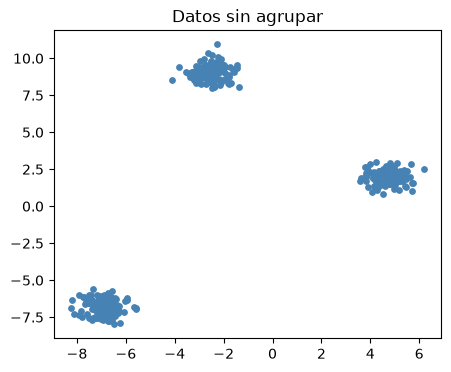

In [2]:
X, _ = make_blobs(n_samples=400, centers=3, cluster_std=0.5, random_state=42)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], s=15, color="steelblue")
plt.title("Datos sin agrupar")
plt.show()

## 2. Estandarizar las variables

DBSCAN se basa por completo en distancias: `eps` es un radio fijo, así que si las variables están en escalas muy distintas, una de ellas dominará la distancia sin que eso refleje su verdadera importancia. Por eso siempre se estandariza **antes** de fijar `eps`.

In [3]:
X_scaled = StandardScaler().fit_transform(X)

## 3. Elegir `eps` y `minPts`

- **minPts**: regla práctica, `minPts >= D + 1` (D = número de dimensiones). Con datos ruidosos, `minPts = 2*D` suele ir mejor. Aquí D=2, así que probamos `minPts = 5`.
- **eps**: se calcula la distancia de cada punto a su *k*-ésimo vecino más cercano (k = minPts) y se grafica en orden descendente — el **gráfico de k-distancias**. El "codo" de esa curva separa puntos densos (izquierda) de puntos dispersos (derecha), y ese es el `eps` a usar.

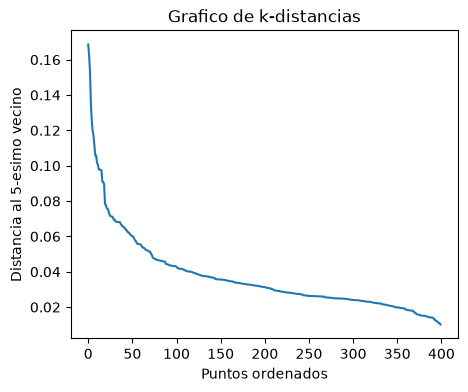

In [4]:
min_pts = 5

neighbors = NearestNeighbors(n_neighbors=min_pts).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])[::-1]  # distancia al k-esimo vecino, descendente

plt.figure(figsize=(5, 4))
plt.plot(k_dist)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_pts}-esimo vecino")
plt.title("Grafico de k-distancias")
plt.show()

In [5]:
# Deteccion automatica del "codo": el punto de maxima curvatura de la curva
# (aproximacion simple, en la practica tambien vale elegirlo a ojo)
diffs = np.diff(k_dist)
elbow_idx = np.argmin(diffs)  # mayor caida entre puntos consecutivos
eps = k_dist[elbow_idx]
print(f"eps sugerido por el codo: {eps:.3f}")

eps sugerido por el codo: 0.153


## 4. Entrenar DBSCAN

No hace falta indicar el número de clusters — DBSCAN lo determina a partir de `eps` y `min_samples`.

In [6]:
db = DBSCAN(eps=eps, min_samples=min_pts)
labels = db.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido: {n_noise} ({n_noise/len(labels):.1%} del total)")

Clusters encontrados: 3
Puntos de ruido: 1 (0.2% del total)


## 5. Visualizar núcleo, borde y ruido

`labels == -1` marca el ruido. Para distinguir núcleo de borde usamos `db.core_sample_indices_`: cualquier punto en esa lista es un **core point**; los que quedaron con una etiqueta de cluster (`label != -1`) pero no están en esa lista son **border points**.

*(Recordatorio: esa etiqueta de ruido es la que quedó al final del algoritmo — durante el proceso, un punto puede empezar como ruido "provisional" y luego reclasificarse como borde si termina dentro del radio `eps` de un núcleo de otro cluster expandido más tarde. `fit_predict` ya nos entrega el resultado final, no las etapas intermedias.)*

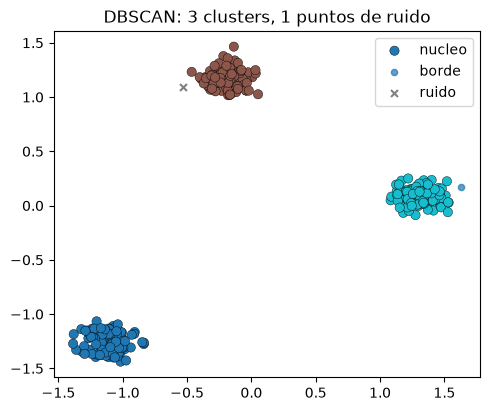

In [7]:
core_mask = np.zeros_like(labels, dtype=bool)
core_mask[db.core_sample_indices_] = True
border_mask = (labels != -1) & (~core_mask)
noise_mask = labels == -1

plt.figure(figsize=(5.5, 4.5))
plt.scatter(X_scaled[core_mask, 0], X_scaled[core_mask, 1],
            c=labels[core_mask], cmap="tab10", s=45, label="nucleo", edgecolor="k", linewidth=0.3)
plt.scatter(X_scaled[border_mask, 0], X_scaled[border_mask, 1],
            c=labels[border_mask], cmap="tab10", s=20, alpha=0.7, label="borde")
plt.scatter(X_scaled[noise_mask, 0], X_scaled[noise_mask, 1],
            c="gray", marker="x", s=25, label="ruido")
plt.legend()
plt.title(f"DBSCAN: {n_clusters} clusters, {n_noise} puntos de ruido")
plt.show()

## 6. Bonus: formas no convexas

K-Medias solo puede trazar fronteras rectas entre centroides, así que falla con clusters no convexos. DBSCAN, al definir clusters por densidad y no por cercanía a un centro, no tiene ese problema.

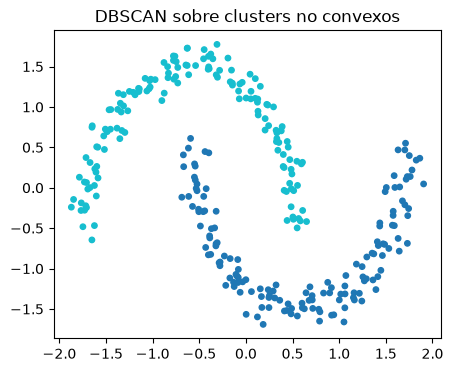

In [8]:
from sklearn.datasets import make_moons

X_moons, _ = make_moons(n_samples=300, noise=0.06, random_state=42)
X_moons_scaled = StandardScaler().fit_transform(X_moons)
labels_moons = DBSCAN(eps=0.25, min_samples=5).fit_predict(X_moons_scaled)

plt.figure(figsize=(5, 4))
plt.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=labels_moons, cmap="tab10", s=15)
plt.title("DBSCAN sobre clusters no convexos")
plt.show()

## Resumen

- `eps` y `minPts` definen la densidad mínima de un cluster; el gráfico de k-distancias ayuda a elegir `eps` de forma menos arbitraria.
- Un punto es **núcleo** si tiene ≥ minPts vecinos en su radio eps, **borde** si está en el radio eps de un núcleo pero no lo es él mismo, y **ruido** si no cumple ninguna de las dos.
- No hace falta fijar el número de clusters de antemano, y el algoritmo maneja bien formas arbitrarias — a cambio de ser sensible a la elección de `eps`/`minPts` y de tener dificultades con densidades muy distintas entre clusters.